In [1]:
# READ ME
# -------------------------------------------------------------------
print("""
    This Jupyter Notebook file provides an example of the epidemiological modeling conducted in the manuscript titled,
    Informing an mpox stockpile investment case: epidemiological modelling and cost-benefit analysis.The code below
    creates an epidemiological model of mpox disease transmission in the archetypal setting of the Mushin Local
    Government Area, Lagos, Nigeria, demonstrating various vaccine strategies of a 1-dose and 2-dose vaccine
    strategies with immediate and delayed initiation of the strategy. Note, generative AI was used to assist in design
    and refinement of the epidemiological model.
    
    Prior to running the code below, please import the necessary packages and set a working directory. To adapt
    this code for use with the other two archetypal settings, use the model parameters from Table S2 to update 
    Step #3.
    
   Questions regarding the following .do file should be sent to the corresponding author, Dr. Crystal R. Watson
   (cori@jh.edu).
    """)
# -------------------------------------------------------------------


    This Jupyter Notebook file provides an example of the epidemiological modeling conducted in the manuscript titled,
    Informing an mpox stockpile investment case: epidemiological modelling and cost-benefit analysis.The code below
    creates an epidemiological model of mpox disease transmission in the archetypal setting of the Mushin Local
    Government Area, Lagos, Nigeria, demonstrating various vaccine strategies of a 1-dose and 2-dose vaccine
    strategies with immediate and delayed initiation of the strategy. Note, generative AI was used to assist in design
    and refinement of the epidemiological model.
    
    Prior to running the code below, please import the necessary packages and set a working directory. To adapt
    this code for use with the other two archetypal settings, use the model parameters from Table S2 to update 
    Step #3.Generative AI was used to assist in design and refinement of the epidemiological model.

    Questions regarding the following .do fil

In [2]:
# Step 1. Import pertinent packages
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm
import contextlib

# Set working directory
#os.chdir('C:/Users/')

print(f"Current working directory: {os.getcwd()}")

Current working directory: C:\Users\

In [3]:
# Step 2. Results folder setup
def setup_results_folder():
    results_folder_name = "RESULTS_FOLDER_NI"
    os.makedirs(results_folder_name, exist_ok=True)
    return results_folder_name

RESULTS_FOLDER_NI = setup_results_folder()

In [4]:
# Step 3. Model parameters - Mushin Local Government Area, Lagos, Nigeria
# Population parameters
TOTAL_POPULATION = 935400
INITIAL_INFECTED = 20 #either 20 or 100

# Group definitions
GROUP_FRACTIONS = {
    'msm': 0.0006,
    'sw': 0.0055,
    'children': 0.16,
    'general': 0.8339
}

RISK_FACTORS = {
    'msm': 2.0,
    'sw': 4.0,
    'children': 1.5,
    'general': 1.0
}
CFR = {
    'msm': 0.011,
    'sw': 0.011,
    'children': 0.036,
    'general': 0.001
}

# Disease parameters
DEFAULT_BETA = 0.086
BETA_CV = 0.15
SIGMA = 1/8.6  # incubation rate
GAMMA = 1/21   # recovery rate
VACCINE_DELAY = 5
VACCINE_DELAY_RATE = 1 / VACCINE_DELAY
VACCINE_EFFICACIES = [0.75, 0.82]
CONTACT_DURATION = 5
CONTACT_REMOVAL_RATE = 1 / CONTACT_DURATION

# Derived parameters
POPULATION = {k: int(TOTAL_POPULATION * v) for k, v in GROUP_FRACTIONS.items()}

print(f"Total population: {TOTAL_POPULATION:,}")
print(f"Population by group: {POPULATION}")

Total population: 935,400
Population by group: {'msm': 561, 'sw': 5144, 'children': 149664, 'general': 780030}


In [5]:
# Step 4. Establish initial state vector, get strategy, and SEIRDV ODE function
def init_state_with_minimums():
    """Initial state vector with minimum infections per group"""
    state = np.zeros(32)
    group_indices = {'msm': 0, 'sw': 8, 'children': 16, 'general': 24}
    total_risk = sum(GROUP_FRACTIONS[g] * RISK_FACTORS[g] for g in GROUP_FRACTIONS)
    remaining_infected = INITIAL_INFECTED
    
    # Ensure at least 1 case per group
    for g, idx in group_indices.items():
        N = POPULATION[g]
        min_infected = max(1, int(INITIAL_INFECTED * GROUP_FRACTIONS[g] * RISK_FACTORS[g] / total_risk))
        min_infected = min(min_infected, remaining_infected, N)
        state[idx] = N - min_infected      # S
        state[idx + 2] = min_infected      # I
        remaining_infected -= min_infected
    
    # Distribute remaining infections to the general population
    if remaining_infected > 0:
        state[group_indices['general'] + 2] += remaining_infected
        state[group_indices['general']] -= remaining_infected
    
    print("Initial infections by group:")
    for g, idx in group_indices.items():
        print(f"  {g}: {state[idx+2]:.0f} infections (population: {POPULATION[g]})")
    
    return state

def get_strategy(strategy_type, beta=DEFAULT_BETA, pct_vaccinated=0.5, 
                      pct_traced=0.5, vaccine_efficacy=0.75):
    """Strategy function with crossover parameters"""
    
    base_strategy = {
        'vaccine_efficacy': vaccine_efficacy,
        'v_mass': {k: 0 for k in GROUP_FRACTIONS},
        'v_contacts': {k: 0 for k in GROUP_FRACTIONS},
        'contact_tracing_rate': {k: 0 for k in GROUP_FRACTIONS},
        'crossover_beta': 0
    }
    
    if strategy_type == 'mass':
        base_strategy.update({
            'v_mass': {k: pct_vaccinated if k != 'general' else 0 for k in GROUP_FRACTIONS}
        })
    
    elif strategy_type == 'contact_tracing':
        base_strategy.update({
            'v_contacts': {k: vaccine_efficacy for k in GROUP_FRACTIONS},
            'contact_tracing_rate': {k: pct_traced * 15 for k in GROUP_FRACTIONS}
        })
    
    elif strategy_type == 'crossover':
        base_strategy.update({
            'v_mass': {k: pct_vaccinated if k != 'general' else 0 for k in GROUP_FRACTIONS},
            'v_contacts': {k: vaccine_efficacy for k in GROUP_FRACTIONS},
            'contact_tracing_rate': {k: pct_traced * 15 for k in GROUP_FRACTIONS},
            'crossover_beta': beta * 0.3
        })
    
    elif strategy_type == 'none':
        base_strategy.update({
            'vaccine_efficacy': 0
        })
    
    return base_strategy

def seirdv_ode_unified(y, t, beta, strategy_params, detection_rate=0.5, vaccination_start_day=None, case_threshold=100):
    """
    SEIRDV ODE function with proper vaccine efficacy, crossover effects, and includes both immediate delayed vaccination strategy
    - If vaccination_start_day is None: uses case_threshold (default 100) to trigger vaccination
    - If vaccination_start_day is provided: uses specific day
    - If vaccination_start_day is 0: immediate vaccination
    """
    dydt = np.zeros_like(y)
    
    # Calculate crossover effect
    I_high_risk = 0
    N_high_risk = 0
    for i in range(3):  # MSM, SW, children
        base = i * 8
        I_high_risk += y[base + 2]
        N_high_risk += sum(y[base:base+6])
    
    crossover_beta = strategy_params.get('crossover_beta', 0)
    high_risk_foi = crossover_beta * I_high_risk / N_high_risk if N_high_risk > 0 else 0
    
    # Get vaccine efficacy
    vaccine_efficacy = strategy_params.get('vaccine_efficacy', 0)
    
    # Determine if vaccination should be active
    vaccination_active = True  # Default for immediate vaccination strategy
    
    if vaccination_start_day is not None:
        if vaccination_start_day > 0:
            vaccination_active = (t >= vaccination_start_day)
    else:
        # Use case threshold
        cumulative_cases = 0
        for i in range(4):
            base = i * 8
            cumulative_cases += y[base + 3] + y[base + 4]  # R + D
        vaccination_active = (cumulative_cases >= case_threshold)
    
    for i, group in enumerate(['msm', 'sw', 'children', 'general']):
        base = i * 8
        S, E, I, R, D, V, C, C_V = y[base:base+8]
        N = S + E + I + R + V + C + C_V
        r = RISK_FACTORS[group]
        delta = CFR[group]
        
        # Extinction factor for small outbreaks
        extinction_factor = 1.0
        if I < 5:
            extinction_factor = max(0.2, I/5)
        
        # Base transmission
        lambda_g = (beta * r * I / N) * extinction_factor if N > 0 else 0
        
        # Apply crossover effect to general population
        if group == 'general':
            lambda_g += high_risk_foi * extinction_factor
        
        # Apply vaccine efficacy
        lambda_unvaccinated = lambda_g
        lambda_vaccinated = lambda_g * (1 - vaccine_efficacy)
        
        # Vaccination rates (only applied if vaccination strategy has been initiated)
        if vaccination_active:
            v_mass = strategy_params.get('v_mass', {}).get(group, 0)
            v_contacts = strategy_params.get('v_contacts', {}).get(group, 0)
            contact_rate = strategy_params.get('contact_tracing_rate', {}).get(group, 0)
        else:
            v_mass = 0
            v_contacts = 0
            contact_rate = 0
        
        # Contact tracing
        new_contacts = contact_rate * detection_rate * I
        
        # Differential equations
        dS = -lambda_unvaccinated * S - v_mass * S - new_contacts
        dE = (lambda_unvaccinated * S + 
              lambda_vaccinated * C + 
              lambda_vaccinated * C_V) - SIGMA * E
        dI = SIGMA * E - GAMMA * I
        dR = GAMMA * I * (1 - delta)
        dD = GAMMA * I * delta
        dV = v_mass * S + v_contacts * C_V
        dC = new_contacts - VACCINE_DELAY_RATE * C - lambda_vaccinated * C
        dC_V = VACCINE_DELAY_RATE * C - v_contacts * C_V - lambda_vaccinated * C_V
        
        dydt[base:base+8] = [dS, dE, dI, dR, dD, dV, dC, dC_V]
    
    return dydt

In [6]:
# Step 5: Simulation function that includes both immediate and delayed vaccination
def run_sim(strategy, beta=DEFAULT_BETA, detection_rate=0.5, days=180, 
                   vaccination_start_day=0, case_threshold=100):
    """
   Simimulation function includes both immediate and delayed vaccination
    - vaccination_start_day=0: immediate vaccination (default)
    - vaccination_start_day>0: vaccination starts on specific day
    - vaccination_start_day=None: vaccination starts when case_threshold is reached
    """
    y0 = init_state_with_minimums()
    t = np.linspace(0, days, days + 1)
    result = solve_ivp(
        lambda t, y: seirdv_ode_unified(y, t, beta, strategy, detection_rate, vaccination_start_day, case_threshold),
        [0, days],
        y0,
        t_eval=t,
        method='LSODA',
        rtol=1e-6,
        atol=1e-9
    )
    
    if not result.success:
        print(f"Warning: Simulation failed: {result.message}")
    return result.t, result.y.T

def extract_metrics(sol):
    """Extract summary statistics from simulation results"""
    metrics = {
        'deaths': {},
        'cases': {},
        'vaccinated': {}
    }
    
    for i, group in enumerate(['msm', 'sw', 'children', 'general']):
        base = i * 8
        metrics['deaths'][group] = sol[-1, base + 4]
        metrics['cases'][group] = sol[-1, base + 3] + sol[-1, base + 4]
        metrics['vaccinated'][group] = sol[-1, base + 5]
    
    # Calculate totals
    for metric in metrics:
        metrics[metric]['total'] = sum(metrics[metric].values())
    
    return metrics

def find_vaccination_start_day (beta, case_threshold=100, max_days=60):

    """Optimized calculation using analytical approximation instead of full simulation
    to prevent major bottlenecks and resulting stahlling of the model"""

    # Simplified exponential growth model instead of full simulation
    r0_estimate = beta * 21  # Rough R0 estimate (beta * infectious_period)
    if r0_estimate <= 1:
        return None
        
    # Exponential growth: N(t) = N0 * exp(r*t), where r = (R0-1)/generation_time
    generation_time = 8.6 + 21  # Incubation + infectious period
    growth_rate = (r0_estimate - 1) / generation_time
   
    # Solve for t when N(t) = case_threshold
    import math
    try:
        days_to_threshold = math.log(case_threshold / INITIAL_INFECTED) / growth_rate
        return min(max_days, max(1, days_to_threshold))
    except:
        return max_days / 2  # Fallback

In [7]:
# Step 6. Monte Carlo function
def monte_carlo(runs=1000, vary_all=True, case_threshold=100):
    import gc
    print(f"Running Monte Carlo simulation with {runs} runs...")
    results = []
    failed_runs = 0
    for i in tqdm(range(runs), desc="Running comparison of vaccination strategies"):
        try:
            # Generate parameters
            beta = np.random.lognormal(
                mean=np.log(DEFAULT_BETA) - 0.5 * np.log(1 + BETA_CV**2),
                sigma=np.sqrt(np.log(1 + BETA_CV**2))
            )
            beta = np.clip(beta, 0.01, 0.3)
            if vary_all:
                detection_rate = np.random.uniform(0.3, 0.8)
                pct_vaccinated = np.random.uniform(0.3, 0.8)
                pct_traced = np.random.uniform(0.3, 0.8)
            else:
                detection_rate = 0.5
                pct_vaccinated = 0.5
                pct_traced = 0.5
            result = {
                'run_id': i + 1,
                'beta': beta,
                'detection_rate': detection_rate,
                'pct_vaccinated': pct_vaccinated,
                'pct_traced': pct_traced,
            }
        
            vaccination_start_day = find_vaccination_start_day(beta, case_threshold)
            # Scenario 1: No vaccine
            strategy_none = get_strategy('none', beta=beta, 
                                             pct_vaccinated=pct_vaccinated, 
                                             pct_traced=pct_traced, 
                                             vaccine_efficacy=0)
            _, sol_none = run_sim(strategy_none, beta, detection_rate, vaccination_start_day=0)
            metrics_none = extract_metrics(sol_none)
            result['no_vaccine_cases'] = metrics_none['cases']['total']
            result['no_vaccine_deaths'] = metrics_none['deaths']['total']
            result['no_vaccine_vaccinated'] = 0
            
            # Skip unrealistic scenarios
            if metrics_none['cases']['total'] > TOTAL_POPULATION * 0.9:
                continue
            # Vaccination scenarios (only if a reasonable vaccination start day)
            if vaccination_start_day is not None and vaccination_start_day < 100:
                # 75% efficacy scenarios
                strategy_75 = get_strategy('crossover', beta=beta, 
                                               pct_vaccinated=pct_vaccinated, 
                                               pct_traced=pct_traced, 
                                               vaccine_efficacy=0.75)
                
                # Immediate 75% - 1 dose
                _, sol_immediate_75 = run_sim(strategy_75, beta, detection_rate, vaccination_start_day=0)
                metrics_immediate_75 = extract_metrics(sol_immediate_75)
                result['immediate_75_cases'] = metrics_immediate_75['cases']['total']
                result['immediate_75_deaths'] = metrics_immediate_75['deaths']['total']
                result['immediate_75_vaccinated'] = metrics_immediate_75['vaccinated']['total']
                
                # Delayed 75% - 1 dose
                _, sol_delayed_75 = run_sim(strategy_75, beta, detection_rate, 
                                                  vaccination_start_day=vaccination_start_day)
                metrics_delayed_75 = extract_metrics(sol_delayed_75)
                result['delayed_75_cases'] = metrics_delayed_75['cases']['total']
                result['delayed_75_deaths'] = metrics_delayed_75['deaths']['total']
                result['delayed_75_vaccinated'] = metrics_delayed_75['vaccinated']['total']
                
                # 82% efficacy scenarios
                strategy_82 = get_strategy('crossover', beta=beta, 
                                               pct_vaccinated=pct_vaccinated, 
                                               pct_traced=pct_traced, 
                                               vaccine_efficacy=0.82)
                
                # Immediate 82% - 2 doses
                _, sol_immediate_82 = run_sim(strategy_82, beta, detection_rate, vaccination_start_day=0)
                metrics_immediate_82 = extract_metrics(sol_immediate_82)
                result['immediate_82_cases'] = metrics_immediate_82['cases']['total']
                result['immediate_82_deaths'] = metrics_immediate_82['deaths']['total']
                result['immediate_82_vaccinated'] = metrics_immediate_82['vaccinated']['total']
                
                # Delayed 82% - 2 doses
                _, sol_delayed_82 = run_sim(strategy_82, beta, detection_rate,
                                                  vaccination_start_day=vaccination_start_day)
                metrics_delayed_82 = extract_metrics(sol_delayed_82)
                result['delayed_82_cases'] = metrics_delayed_82['cases']['total']
                result['delayed_82_deaths'] = metrics_delayed_82['deaths']['total']
                result['delayed_82_vaccinated'] = metrics_delayed_82['vaccinated']['total']
                
            else:
                #if vaccination doesn't start, copy no-vaccine results
                for efficacy in ['75', '82']:
                    for timing in ['immediate', 'delayed']:
                        result[f'{timing}_{efficacy}_cases'] = metrics_none['cases']['total']
                        result[f'{timing}_{efficacy}_deaths'] = metrics_none['deaths']['total']
                        result[f'{timing}_{efficacy}_vaccinated'] = 0
            result['vaccination_start_day'] = vaccination_start_day
            results.append(result)
            
            # Garbage collection every 50 runs to prevent memory issues and ensure the code runs smoothly
            if i % 50 == 0:
                gc.collect()
                print(f"Completed {i+1}/{runs} runs... (Memory cleared)")
                
        except Exception as e:
            failed_runs += 1
            print(f"Run {i+1} failed: {e}")
            if failed_runs > runs * 0.1:  # Stop if >10% fail
                print(f"Too many failures ({failed_runs}), stopping early")
                break
                
    print(f"Completed {len(results)} successful runs out of {runs} attempted")
    print(f"Failed runs: {failed_runs}")
    
    # Save results
    df = pd.DataFrame(results)
    csv_path = os.path.join(RESULTS_FOLDER_NI, "vaccination_analysis.csv")
    df.to_csv(csv_path, index=False)
    print(f"Results saved to: {csv_path}")
    
    return df
    return monte_carlo(runs, vary_all, case_threshold)

In [8]:
# Step 7. Analysis and visualization functions for testing the crossover effect
def test_crossover():
    """Test crossover effect"""
    print("Testing crossover effect...")
    
    # Strategies
    strategy_with = get_strategy('crossover', pct_vaccinated=0.5, 
                                     pct_traced=0.5, vaccine_efficacy=0.75)
    strategy_without = strategy_with.copy()
    strategy_without['crossover_beta'] = 0
    
    print(f"Crossover beta WITH: {strategy_with['crossover_beta']:.4f}")
    print(f"Crossover beta WITHOUT: {strategy_without['crossover_beta']}")
    
    # Run simulations
    t1, sol1 = run_sim(strategy_with)
    t2, sol2 = run_sim(strategy_without)
    
    # Results
    general_with = sol1[-1, 26]
    general_without = sol2[-1, 26]
    difference = general_with - general_without
    
    print(f"Final general infections WITH crossover: {general_with:.2f}")
    print(f"Final general infections WITHOUT crossover: {general_without:.2f}")
    print(f"Difference (crossover effect): {difference:.2f}")
    
    # Save results
    results_data = {
        'scenario': ['with_crossover', 'without_crossover'],
        'crossover_beta': [strategy_with['crossover_beta'], 0],
        'final_general_infections': [general_with, general_without],
        'peak_general_infections': [np.max(sol1[:, 26]), np.max(sol2[:, 26])]
    }
    
    results_df = pd.DataFrame(results_data)
    csv_file = os.path.join(RESULTS_FOLDER_NI, "crossover_test_results.csv")
    results_df.to_csv(csv_file, index=False)
    print(f"Results saved to: {csv_file}")
    
    # Save plot
    plt.figure(figsize=(12, 8))
    
    # Plot 1: General population
    plt.subplot(2, 2, 1)
    plt.plot(t1, sol1[:, 26], label='With Crossover', color='red', linewidth=2)
    plt.plot(t2, sol2[:, 26], label='Without Crossover', color='blue', linewidth=2)
    plt.xlabel('Days')
    plt.ylabel('Infectious in General Population')
    plt.title('Crossover Effect: General Population')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: High-risk groups
    plt.subplot(2, 2, 2)
    high_risk_with = sol1[:, 2] + sol1[:, 10] + sol1[:, 18]
    high_risk_without = sol2[:, 2] + sol2[:, 10] + sol2[:, 18]
    
    plt.plot(t1, high_risk_with, label='With Crossover', color='red', linewidth=2)
    plt.plot(t2, high_risk_without, label='Without Crossover', color='blue', linewidth=2)
    plt.xlabel('Days')
    plt.ylabel('Infectious in High-Risk Groups')
    plt.title('High-Risk Group Infections')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Total infections
    plt.subplot(2, 2, 3)
    total_with = sol1[:, 2] + sol1[:, 10] + sol1[:, 18] + sol1[:, 26]
    total_without = sol2[:, 2] + sol2[:, 10] + sol2[:, 18] + sol2[:, 26]
    
    plt.plot(t1, total_with, label='With Crossover', color='red', linewidth=2)
    plt.plot(t2, total_without, label='Without Crossover', color='blue', linewidth=2)
    plt.xlabel('Days')
    plt.ylabel('Total Infectious')
    plt.title('Total Infections')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Peak comparison
    plt.subplot(2, 2, 4)
    categories = ['With Crossover', 'Without Crossover']
    peaks = [np.max(sol1[:, 26]), np.max(sol2[:, 26])]
    
    bars = plt.bar(categories, peaks, color=['red', 'blue'], alpha=0.7)
    plt.ylabel('Peak General Infections')
    plt.title('Peak Comparison')
    
    for bar, value in zip(bars, peaks):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(peaks)*0.01,
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Save as a graphic of the combined plots
    plot_file = os.path.join(RESULTS_FOLDER_NI, "crossover_effect_analysis.png")
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {plot_file}")
    plt.show()
    
    return results_df

def plot_histograms(df, scenario_prefix, scenario_name, metrics=['cases', 'deaths', 'vaccinated']):
    """Histogram plotting"""
    print(f"Creating histograms for {scenario_name}...")
    
    # Find available metric columns
    available_cols = []
    for metric in metrics:
        col = f'{scenario_prefix}_{metric}'
        if col in df.columns:
            available_cols.append(col)
    
    if not available_cols:
        print(f"No metric columns found for {scenario_name}")
        return None
    
    # Create figure
    n_cols = len(available_cols)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange']
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
        
        data = df[col].dropna()
        if len(data) == 0:
            continue
        
        # Create histogram
        axes[i].hist(data, bins=25, alpha=0.7, color=colors[i % len(colors)], 
                    edgecolor='black', linewidth=0.5)
        
        # Add statistics
        mean_val = data.mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2)
        axes[i].text(0.05, 0.95, f'Mean: {mean_val:.1f}', 
                    transform=axes[i].transAxes, 
                    bbox=dict(facecolor='white', alpha=0.8))
        
        # Labels
        axes[i].set_xlabel(col.replace('_', ' ').title())
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{col.replace("_", " ").title()}')
        axes[i].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(available_cols), len(axes)):
        axes[i].set_visible(False)
     
    fig.suptitle(f'{scenario_name} Results', fontsize=14)
    plt.tight_layout()
    
    # Save histograms
    filename = f"{scenario_prefix}_histograms.png"
    filepath = os.path.join(RESULTS_FOLDER_NI, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Histograms saved to: {filepath}")
    plt.show()
    
    return fig

def create_strategy_comparison(strategy_dfs):
    """Create and save strategy comparison table"""
    print("Creating strategy comparison table...")
    
    comparison_data = []
    for strategy_name, df in strategy_dfs.items():
        row = {'Strategy': strategy_name}
        
        # Add metrics
        for metric in ['cases', 'deaths', 'vaccinated']:
            col = f'{metric}_total' if f'{metric}_total' in df.columns else metric
            if col in df.columns:
                row[f'{metric.title()}_Mean'] = df[col].mean()
                row[f'{metric.title()}_Std'] = df[col].std()
        
        comparison_data.append(row)
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # Save csv
    csv_path = os.path.join(RESULTS_FOLDER_NI, 'strategy_comparison.csv')
    comparison_df.to_csv(csv_path, index=False)
    print(f"Comparison table saved to: {csv_path}")
    
    return comparison_df

def list_saved_files():
    """List all files in the results folder"""
    print(f"\nFiles in results folder ({RESULTS_FOLDER_NI}):")
    print("="*50)
    
    if os.path.exists(RESULTS_FOLDER_NI):
        files = [f for f in os.listdir(RESULTS_FOLDER_NI) 
                if os.path.isfile(os.path.join(RESULTS_FOLDER_NI, f))]
        
        if files:
            for i, filename in enumerate(sorted(files), 1):
                filepath = os.path.join(RESULTS_FOLDER_NI, filename)
                size = os.path.getsize(filepath)
                print(f"{i:2d}. {filename} ({size:,} bytes)")
        else:
            print("No files found")
    else:
        print("Results folder doesn't exist!")

In [9]:
# Step 8. Main SEIRD-V model with both immediate and delayed vaccination strategies
def analyze_results(df):
    """
    Analysis of results with histograms for immediate and delayed vaccination strategies with vaccine efficacy of 75% (1-dose) and 82% (2-dose)
    """
    print("="*60)
    print("Analysis of results.")
    print("="*60)
    
    # Calculate summary statistics
    scenarios = ['no_vaccine', 'immediate_75', 'delayed_75', 'immediate_82', 'delayed_82']
    
    print(f"\nSummary Statistics (n={len(df)} simulations):")
    print("-" * 60)
    
    for scenario in scenarios:
        cases_col = f'{scenario}_cases'
        deaths_col = f'{scenario}_deaths'
        vacc_col  = f'{scenario}_vaccinated'
    
        if cases_col in df.columns:
            # Mean, std, n
            cases_mean  = df[cases_col].mean()
            cases_std   = df[cases_col].std(ddof=1)
            n_cases     = df[cases_col].count()
    
            deaths_mean = df[deaths_col].mean()
            deaths_std  = df[deaths_col].std(ddof=1)
            n_deaths    = df[deaths_col].count()
    
            # CI bounds (z=1.96 for 95%)
            cases_lo  = cases_mean  - 1.96 * cases_std  / np.sqrt(n_cases)
            cases_hi  = cases_mean  + 1.96 * cases_std  / np.sqrt(n_cases)
            deaths_lo = deaths_mean - 1.96 * deaths_std / np.sqrt(n_deaths)
            deaths_hi = deaths_mean + 1.96 * deaths_std / np.sqrt(n_deaths)
    
            print(f"\n{scenario.replace('_', ' ').title()}:")
            print(f"  Cases: {cases_mean:,.1f} (95% CI: {cases_lo:,.1f}, {cases_hi:,.1f})")
            print(f"  Deaths: {deaths_mean:,.1f} (95% CI: {deaths_lo:,.1f}, {deaths_hi:,.1f})")
    
            if vacc_col in df.columns and df[vacc_col].mean() > 0:
                vacc_mean = df[vacc_col].mean()
                vacc_std  = df[vacc_col].std(ddof=1)
                n_vacc    = df[vacc_col].count()
                vacc_lo   = vacc_mean - 1.96 * vacc_std / np.sqrt(n_vacc)
                vacc_hi   = vacc_mean + 1.96 * vacc_std / np.sqrt(n_vacc)
                print(f"  Vaccinated: {vacc_mean:,.1f} (95% CI: {vacc_lo:,.1f}, {vacc_hi:,.1f})")

    # Create histograms for 75% and 82% efficacy scenarios
    print(f"\nCreating histograms for efficacy scenarios...")
    
    # Histograms for 75% efficacy scenarios
    plot_histograms(df, 'immediate_75', '75% Efficacy - Immediate Vaccination (1-Dose)')
    plot_histograms(df, 'delayed_75', '75% Efficacy - Delayed Vaccination (1-Dose)')
    
    # Histograms for 82% efficacy scenarios  
    plot_histograms(df, 'immediate_82', '82% Efficacy - Immediate Vaccination (2-Dose)')
    plot_histograms(df, 'delayed_82', '82% Efficacy - Delayed Vaccination (2-Dose)')
    
    # Calculate effectiveness comparisons
    if 'no_vaccine_cases' in df.columns:
        baseline_cases = df['no_vaccine_cases'].mean()
        baseline_deaths = df['no_vaccine_deaths'].mean()
        
        print(f"\nEffectiveness vs No Vaccination:")
        print("-" * 40)
        
        comparisons = [
            ('immediate_75', 'Immediate 75% Efficacy (1-Dose)'),
            ('delayed_75', 'Delayed 75% Efficacy (1-Dose)'),
            ('immediate_82', 'Immediate 82% Efficacy (2-Dose)'),
            ('delayed_82', 'Delayed 82% Efficacy (2-Dose)')
        ]
        
        for scenario_key, scenario_name in comparisons:
            cases_col = f'{scenario_key}_cases'
            deaths_col = f'{scenario_key}_deaths'
            
            if cases_col in df.columns:
                cases_reduction = (1 - df[cases_col].mean() / baseline_cases) * 100
                deaths_reduction = (1 - df[deaths_col].mean() / baseline_deaths) * 100
                
                print(f"{scenario_name}:")
                print(f"  Cases reduced:  {cases_reduction:5.1f}%")
                print(f"  Deaths reduced: {deaths_reduction:5.1f}%")
    
    # Compare immediate vs delayed for same efficacy
    print(f"\nDelayed vs Immediate Vaccination Impact:")
    print("-" * 45)
    
    for efficacy in [75, 82]:
        immediate_cases = df[f'immediate_{efficacy}_cases'].mean()
        delayed_cases = df[f'delayed_{efficacy}_cases'].mean()
        immediate_deaths = df[f'immediate_{efficacy}_deaths'].mean()
        delayed_deaths = df[f'delayed_{efficacy}_deaths'].mean()
        
        additional_cases = delayed_cases - immediate_cases
        additional_deaths = delayed_deaths - immediate_deaths
        cases_increase = (additional_cases / immediate_cases) * 100
        deaths_increase = (additional_deaths / immediate_deaths) * 100
        
        print(f"\n{efficacy}% Efficacy - Cost of Delaying Vaccination:")
        print(f"  Additional cases:  {additional_cases:6.1f} ({cases_increase:+5.1f}%)")
        print(f"  Additional deaths: {additional_deaths:6.1f} ({deaths_increase:+5.1f}%)")
    
    # Analyze vaccination start timing
    if 'vaccination_start_day' in df.columns:
        start_days = df['vaccination_start_day'].dropna()
        if len(start_days) > 0:
            print(f"\nVaccination Start Timing:")
            print(f"  Mean day: {start_days.mean():.1f}")
            print(f"  Median day: {start_days.median():.1f}")
            print(f"  Range: {start_days.min():.0f} - {start_days.max():.0f} days")
            print(f"  Simulations reaching threshold: {len(start_days)}/{len(df)} ({len(start_days)/len(df)*100:.1f}%)")
    
    return df

# Main execution function - SEIRD-V model
def run_seirdv (runs=1000, case_threshold=100):
    """
    Run the SEIRD-V model
    """
    print("="*60)
    print("SEIRD-V model with immediate and delayed vaccination strategies")
    print("="*60)
    print("="*60)
    
    # Set seed for reproducibility
    np.random.seed(42)
    
    # Analysis Part 1. Test crossover effect
    print("\n1. Testing crossover effects...")
    crossover_results = test_crossover()
    
    # Analysis Part 2. Run Monte Carlo simulation
    # Suppress output while running the Monte Carlo simulation
    print("\n2. Running Monte Carlo simulation...")
    with open(os.devnull, 'w') as f:
        with contextlib.redirect_stdout(f):  # Suppress standard output
            df_analysis = monte_carlo(runs=runs, vary_all=True, case_threshold=case_threshold)
    # Uncomment the following line to see results of each of the 1,000 runs of the Monte Carlo Simulation
    # print("Monte Carlo simulation completed.")

    # Analysis Part 3. Analyze results with histograms for 75% and 82% efficacies
    print("\n3. Analyzing results with visualizations...")
    analyze_results(df_analysis)
    
    # Analysis Part 4. Print summary results
    print("\n4. SUMMARY RESULTS:")
    print("="*40)
    scenarios = ['no_vaccine', 'immediate_75', 'delayed_75', 'immediate_82', 'delayed_82']
    for scenario in scenarios:
        cases_col = f'{scenario}_cases'
        deaths_col = f'{scenario}_deaths'
        if cases_col in df_analysis.columns:
            cases_mean = df_analysis[cases_col].mean()
            deaths_mean = df_analysis[deaths_col].mean()
            print(f"{scenario.replace('_', ' ').title()}:")
            print(f"  Cases: {cases_mean:.1f}")
            print(f"  Deaths: {deaths_mean:.1f}")
            
    # Calculate effectiveness
    if 'no_vaccine_cases' in df_analysis.columns:
        baseline_cases = df_analysis['no_vaccine_cases'].mean()
        baseline_deaths = df_analysis['no_vaccine_deaths'].mean()
        print(f"\nVaccine Effectiveness:")
        for scenario_key, scenario_name in [
            ('immediate_75', 'Immediate 75% Efficacy (1-Dose)'),
            ('delayed_75', 'Delayed 75% Efficacy (1-Dose)'),
            ('immediate_82', 'Immediate 82% Efficacy (2-Dose)'),
            ('delayed_82', 'Delayed 82% Efficacy (2-Dose)')
        ]:
            cases_col = f'{scenario_key}_cases'
            deaths_col = f'{scenario_key}_deaths'
            if cases_col in df_analysis.columns:
                cases_reduction = (1 - df_analysis[cases_col].mean() / baseline_cases) * 100
                deaths_reduction = (1 - df_analysis[deaths_col].mean() / baseline_deaths) * 100
                print(f"  {scenario_name}: {cases_reduction:.1f}% fewer cases, {deaths_reduction:.1f}% fewer deaths")
                
    # List all saved files
    print("\n5. Generated files:")
    list_saved_files()
    print("\n" + "="*60)
    print("Analysis complete.")
    print("="*60)
    return {
        'crossover_results': crossover_results,
        'analysis_results': df_analysis
    }

Running with 1000 runs...
SEIRD-V model with immediate and delayed vaccination strategies

1. Testing crossover effects...
Testing crossover effect...
Crossover beta WITH: 0.0258
Crossover beta WITHOUT: 0
Initial infections by group:
  msm: 1 infections (population: 561)
  sw: 1 infections (population: 5144)
  children: 4 infections (population: 149664)
  general: 14 infections (population: 780030)
Initial infections by group:
  msm: 1 infections (population: 561)
  sw: 1 infections (population: 5144)
  children: 4 infections (population: 149664)
  general: 14 infections (population: 780030)
Final general infections WITH crossover: 811.03
Final general infections WITHOUT crossover: 541.07
Difference (crossover effect): 269.96
Results saved to: RESULTS_FOLDER_NI\crossover_test_results.csv
Plot saved to: RESULTS_FOLDER_NI\crossover_effect_analysis.png


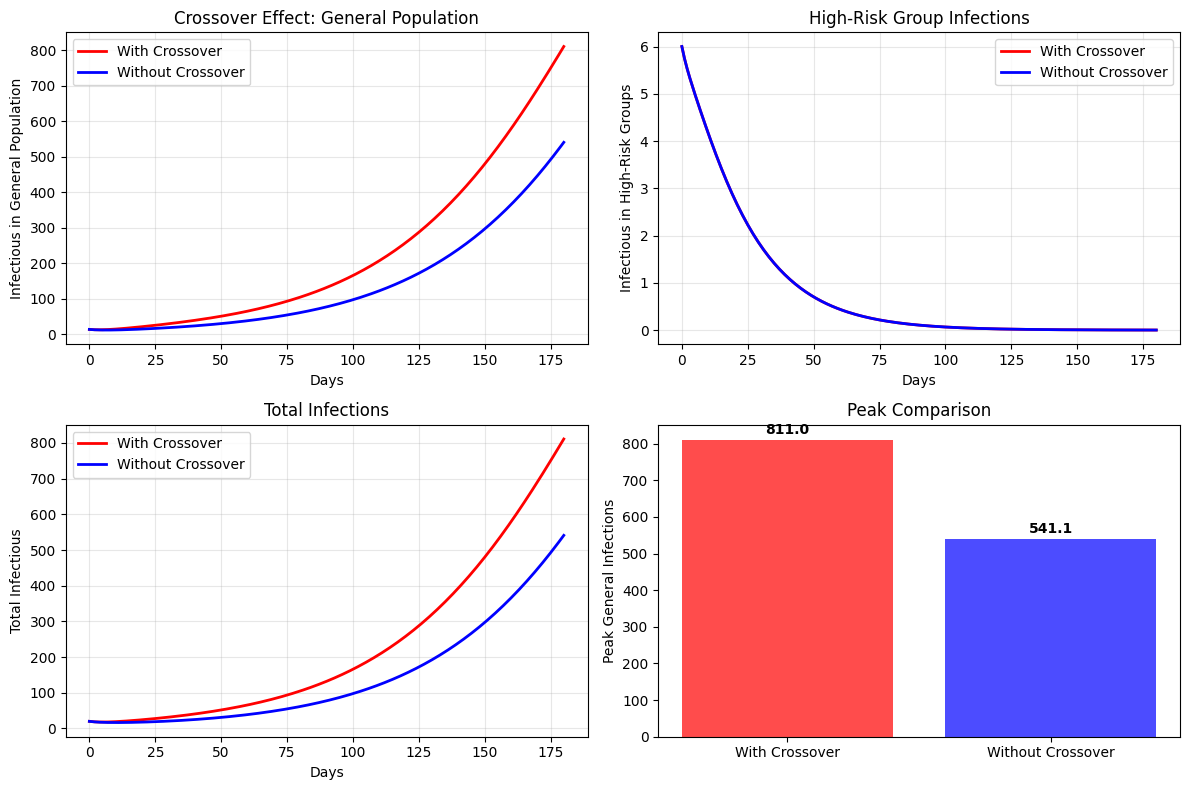

Running comparison of vaccination strategies:   0%|                                           | 0/1000 [00:00<?, ?it/s]


2. Running Monte Carlo simulation...


Running comparison of vaccination strategies: 100%|████████████████████████████████| 1000/1000 [06:02<00:00,  2.75it/s]



3. Analyzing results with visualizations...
Analysis of results.

Summary Statistics (n=1000 simulations):
------------------------------------------------------------

No Vaccine:
  Cases: 17,807.4 (95% CI: 16,494.1, 19,120.7)
  Deaths: 463.8 (95% CI: 427.4, 500.1)

Immediate 75:
  Cases: 2,389.4 (95% CI: 2,264.2, 2,514.6)
  Deaths: 2.6 (95% CI: 2.5, 2.7)
  Vaccinated: 347,724.9 (95% CI: 337,426.5, 358,023.3)

Delayed 75:
  Cases: 4,354.7 (95% CI: 4,190.5, 4,519.0)
  Deaths: 6.6 (95% CI: 6.5, 6.8)
  Vaccinated: 495,978.0 (95% CI: 482,601.1, 509,354.9)

Immediate 82:
  Cases: 2,380.2 (95% CI: 2,256.0, 2,504.5)
  Deaths: 2.6 (95% CI: 2.4, 2.7)
  Vaccinated: 347,390.9 (95% CI: 337,157.4, 357,624.4)

Delayed 82:
  Cases: 4,332.9 (95% CI: 4,170.1, 4,495.8)
  Deaths: 6.6 (95% CI: 6.4, 6.8)
  Vaccinated: 494,769.5 (95% CI: 481,502.4, 508,036.7)

Creating histograms for efficacy scenarios...
Creating histograms for 75% Efficacy - Immediate Vaccination (1-Dose)...
Histograms saved to: RESULTS

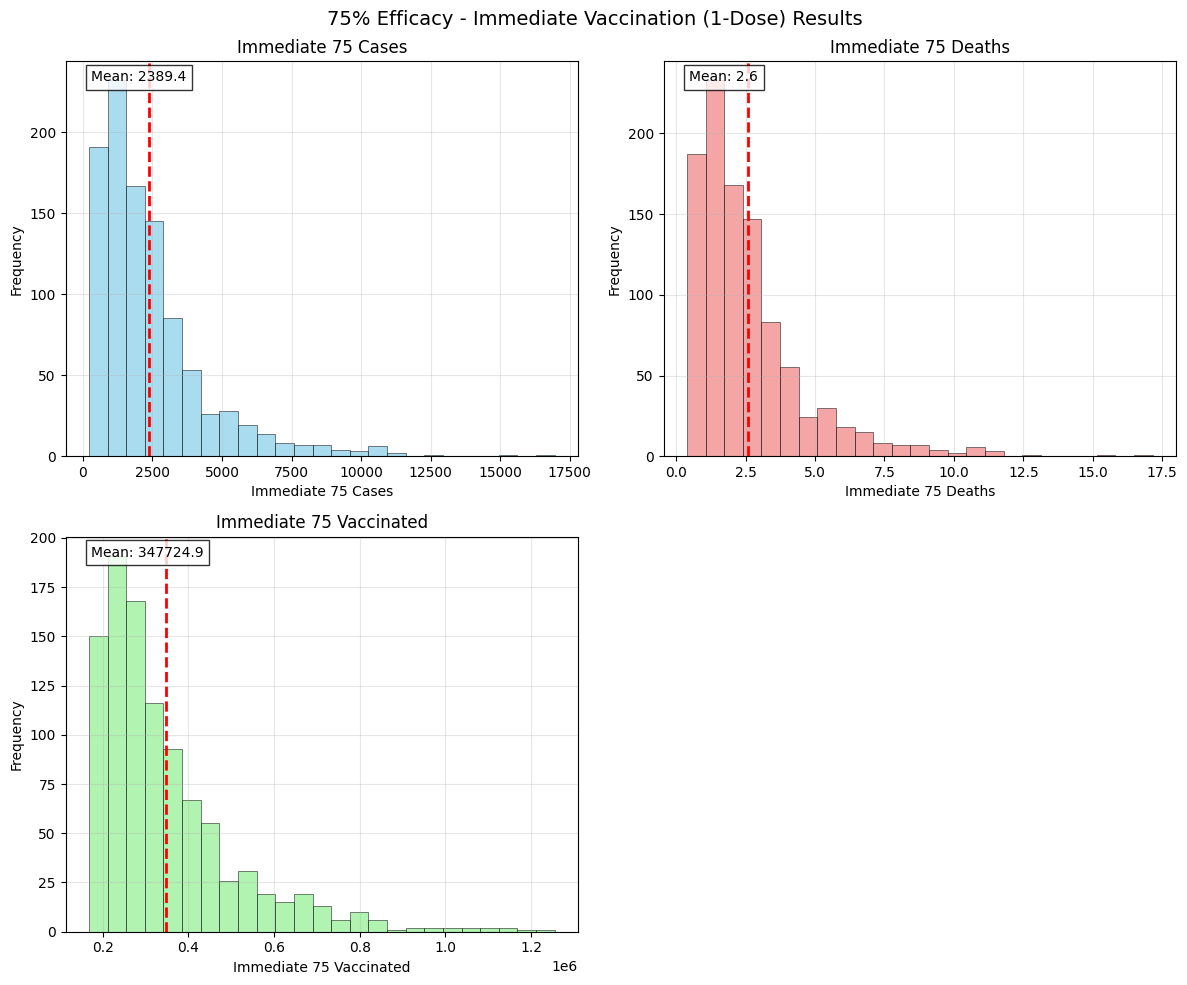

Creating histograms for 75% Efficacy - Delayed Vaccination (1-Dose)...
Histograms saved to: RESULTS_FOLDER_NI\delayed_75_histograms.png


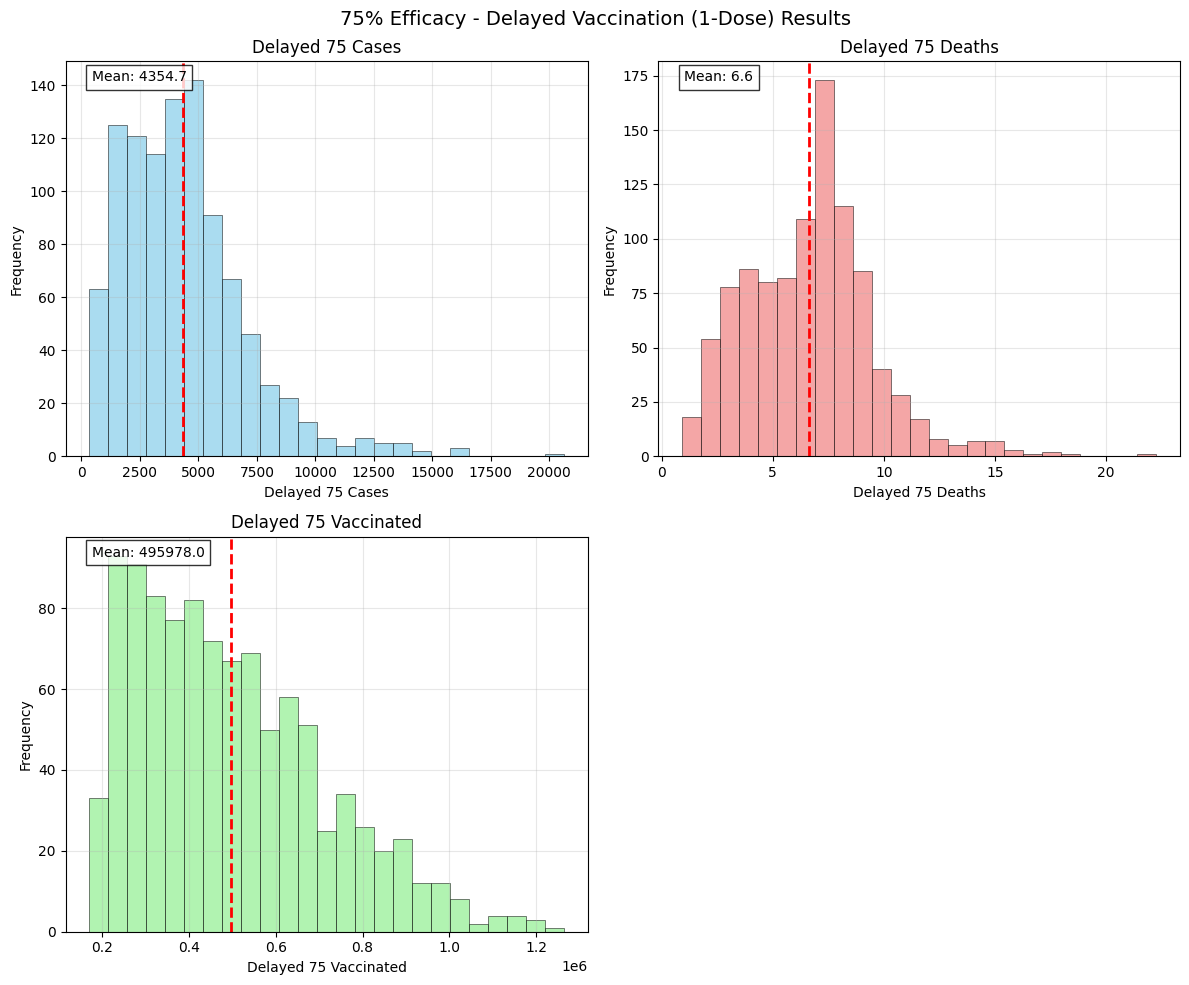

Creating histograms for 82% Efficacy - Immediate Vaccination (2-Dose)...
Histograms saved to: RESULTS_FOLDER_NI\immediate_82_histograms.png


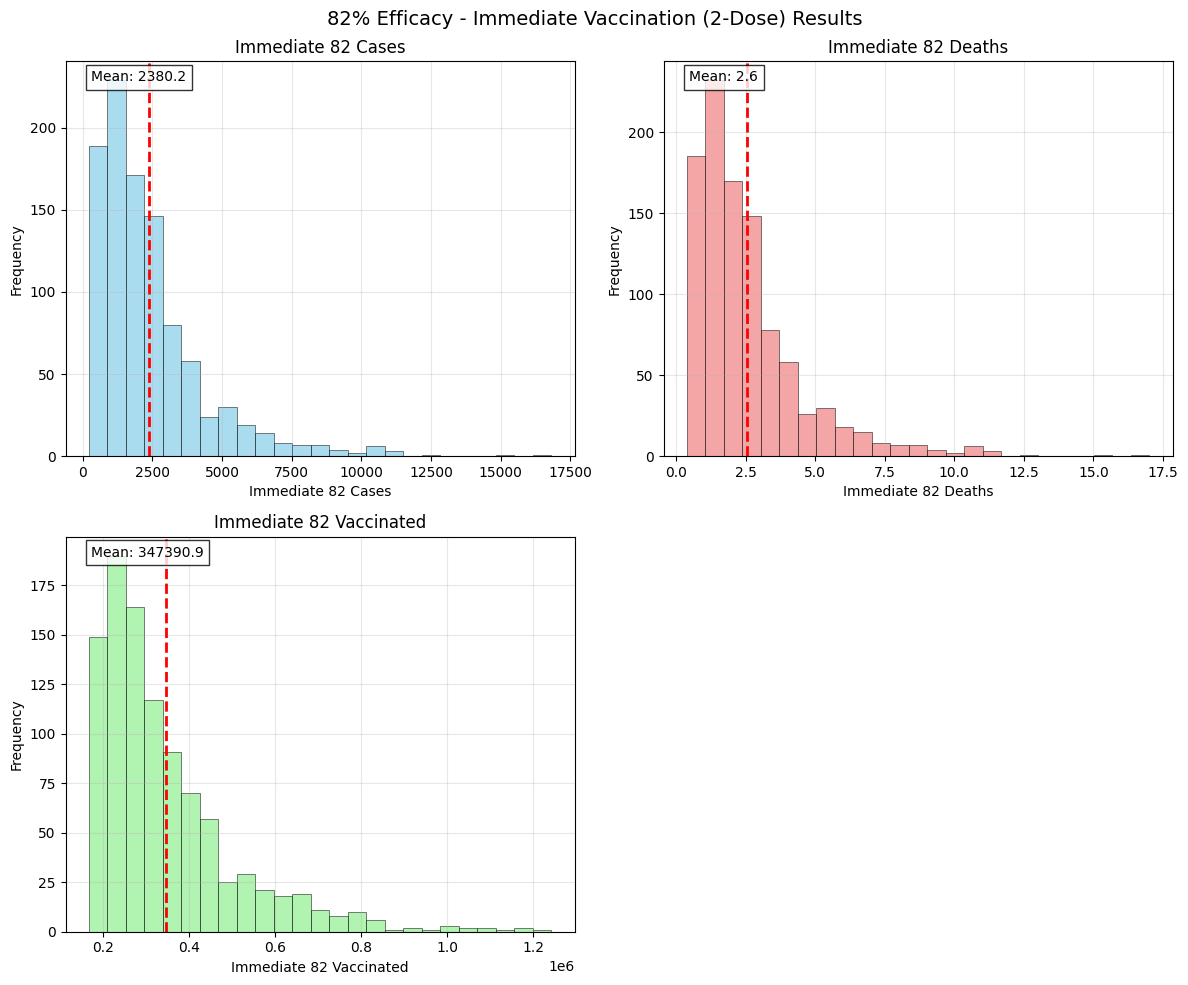

Creating histograms for 82% Efficacy - Delayed Vaccination (2-Dose)...
Histograms saved to: RESULTS_FOLDER_NI\delayed_82_histograms.png


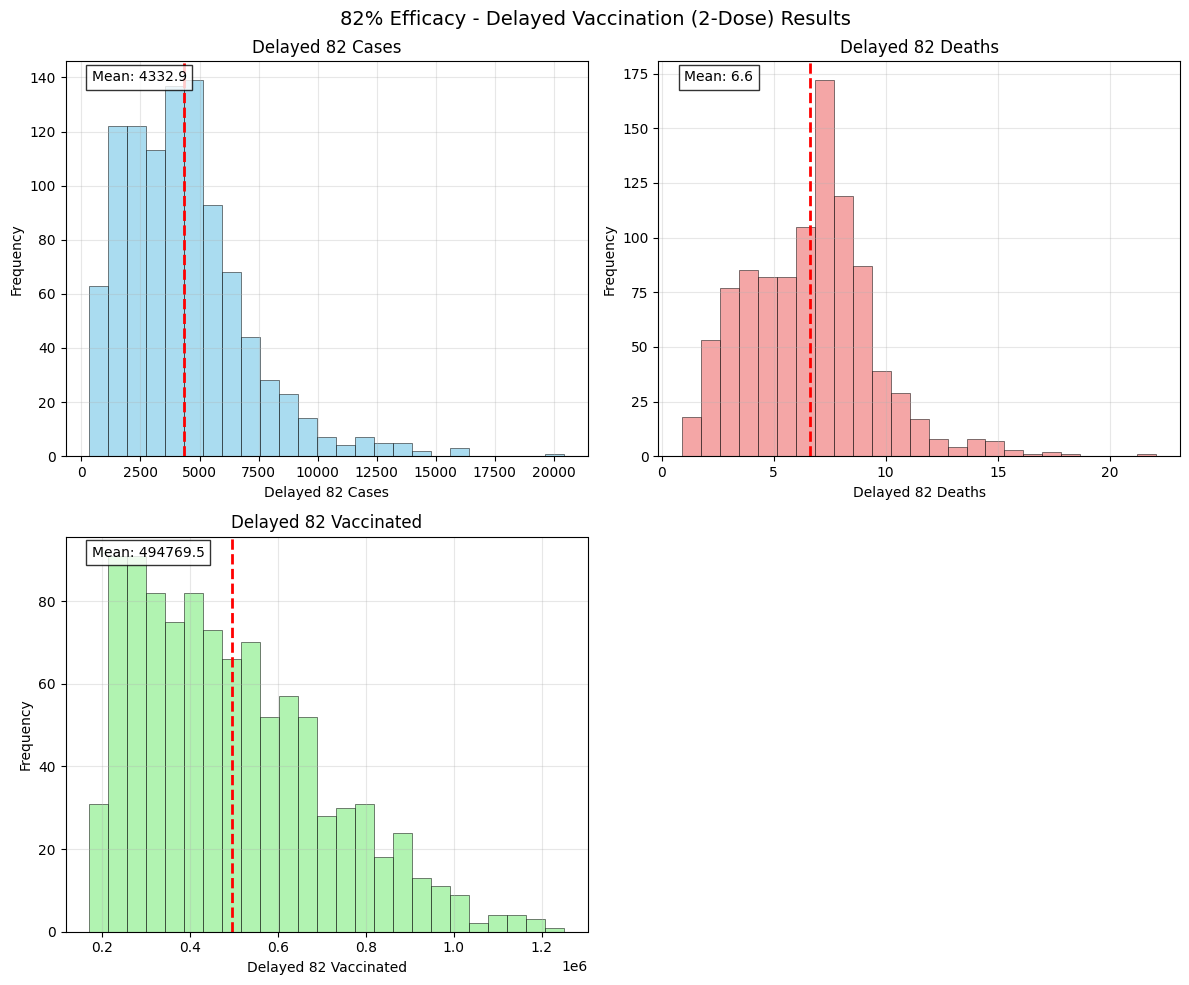


Effectiveness vs No Vaccination:
----------------------------------------
Immediate 75% Efficacy (1-Dose):
  Cases reduced:   86.6%
  Deaths reduced:  99.4%
Delayed 75% Efficacy (1-Dose):
  Cases reduced:   75.5%
  Deaths reduced:  98.6%
Immediate 82% Efficacy (2-Dose):
  Cases reduced:   86.6%
  Deaths reduced:  99.4%
Delayed 82% Efficacy (2-Dose):
  Cases reduced:   75.7%
  Deaths reduced:  98.6%

Delayed vs Immediate Vaccination Impact:
---------------------------------------------

75% Efficacy - Cost of Delaying Vaccination:
  Additional cases:  1965.3 (+82.3%)
  Additional deaths:    4.1 (+157.4%)

82% Efficacy - Cost of Delaying Vaccination:
  Additional cases:  1952.7 (+82.0%)
  Additional deaths:    4.0 (+157.5%)

Vaccination Start Timing:
  Mean day: 54.0
  Median day: 60.0
  Range: 22 - 60 days
  Simulations reaching threshold: 1000/1000 (100.0%)

4. SUMMARY RESULTS:
No Vaccine:
  Cases: 17807.4
  Deaths: 463.8
Immediate 75:
  Cases: 2389.4
  Deaths: 2.6
Delayed 75:
  Cases

In [10]:
# Step 9. Run the Monte Carlo analysis
print("Running with 1000 runs...")
import time
start_time = time.time()
results_full = run_seirdv (runs=1000, case_threshold=100)
full_time = time.time() - start_time
print(f"\nMonte Carlo simulations completed.")
print(f"Total run time: {full_time:.1f} seconds ({full_time/60:.1f} minutes)")
print(f"Successful runs: {len(results_full['analysis_results'])}/1000")

print(f"Analysis completed. ")
print(f"\nAll output saved to: {RESULTS_FOLDER_NI}")
list_saved_files()